# Hamiltonian Flow Matching - Stunnel Potential (2D)

Transports `N([-11, -1], 0.5^2 I)` to `N([11, 1], 0.5^2 I)` in 2D under the `stunnel` crowd-navigation obstacle potential.

The conditional path uses `ParticleBVPGaussianPath`: for each OT-coupled pair `(x0, x1)`, a Hamiltonian BVP `x'' = -grad V(x)` is solved to find a reference trajectory that connects the endpoints while respecting the tunnel-shaped potential landscape.

Workflow:
1. OT-couple a fixed dataset `(x0, x1)`.
2. Solve and cache particle BVPs with `path.batch_solve(x0_dataset, x1_dataset)`.
3. Train a neural velocity field from index-based sampling of the cached BVP pairs.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import torch
device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    CrowdNavObstaclePotential, ParticleBVPGaussianPath, ConfiguredPotential,
    MeanStdBVPGaussianPath,flow_matching_loss, 
    plot_trajectories_with_potential,
)
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import torch_wrapper

def to_numpy(x):
    return x.detach().cpu().numpy()

In [3]:

torch.manual_seed(42)

dim          = 2
batch_size   = 64
n_dataset    = 2_500   # number of pre-computed (x0, x1) pairs
n_iters      = 50_000
lr           = 1e-3
sigma_path   = 1e-4
n_steps      = 50
tol          = 0.1

source_mean  = torch.tensor([-11.0, -1.0],device = device)
target_mean  = torch.tensor([11.0, 1.0],device = device)
gaussian_std = torch.tensor(0.5,device = device)
print(f'device: {device}')

device: cuda:3


## Distributions and Potential

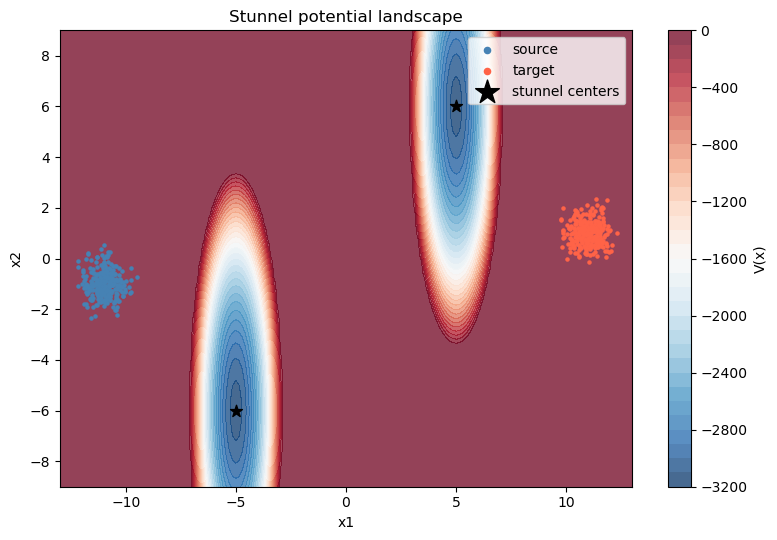

In [4]:
source_dist = MultivariateNormal(source_mean, gaussian_std**2 * torch.eye(dim).to(device))
target_dist = MultivariateNormal(target_mean, gaussian_std**2 * torch.eye(dim).to(device))

def sample_source(n):
    return source_dist.sample((n,)).to(device)

def sample_target(n):
    return target_dist.sample((n,)).to(device)

# potential = CrowdNavObstaclePotential('stunnel')
cfg_potential = {"linear":('stunnel',-35),'interaction':None,'internal':None} #('rational_quadratic', 1.0)
potential = ConfiguredPotential(cfg_potential)
stunnel_centers = torch.tensor([[5.0, 6.0], [-5.0, -6.0]]).to(device)

# Visualize potential landscape with source and target samples.
x_grid = np.linspace(-13, 13, 180)
y_grid = np.linspace(-9, 9, 140)
X, Y = np.meshgrid(x_grid, y_grid)
xy = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32).to(device)

with torch.no_grad():
    Z = to_numpy(potential.energy(xy)).reshape(Y.shape)

x0_vis = to_numpy(sample_source(300))
x1_vis = to_numpy(sample_target(300))
stunnel_centers_plot = to_numpy(stunnel_centers)

plt.figure(figsize=(8, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.75)
plt.colorbar(label='V(x)')
plt.scatter(x0_vis[:, 0], x0_vis[:, 1], s=5, c='steelblue', label='source')
plt.scatter(x1_vis[:, 0], x1_vis[:, 1], s=5, c='tomato', label='target')
plt.scatter(stunnel_centers_plot[:, 0], stunnel_centers_plot[:, 1], s=80, marker='*', c='black', label='stunnel centers')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title('Stunnel potential landscape')
plt.tight_layout()
plt.show()

## Path - Pre-compute BVP Dataset

In [5]:
# path = ParticleBVPGaussianPath(potential, sigma=sigma_path, n_steps=n_steps, tol=tol)
path = MeanStdBVPGaussianPath(potential, sigma=sigma_path, n_steps=n_steps, tol=tol)
ot_sampler = OTPlanSampler(method='exact')

# Step 1: OT-couple the dataset.
x0_all = sample_source(n_dataset)
x1_all = sample_target(n_dataset)
x0_coupled, x1_coupled = ot_sampler.sample_plan(x0_all, x1_all)

print(f'Solving {n_dataset} mean/std BVPs (may take several minutes)...')

# Step 2: Pre-compute BVP for all pairs and drop non-converged solves.
states = path.batch_solve(x0_coupled, x1_coupled)
keep = path.success_mask
x0_coupled = x0_coupled[keep]
x1_coupled = x1_coupled[keep]
n_failed = int((~keep).sum().item())
n_dataset = x0_coupled.shape[0]
print(
    f'Done. kept {n_dataset} / {keep.numel()} BVPs; failed {n_failed}. '
    f'states: {states.shape}  (pairs, time-steps, state-dim [mu, mu_dot, sigma, sigma_dot])'
)
if n_failed:
    preview = list(path.failure_messages.items())[:5]
    print(f'First failures: {preview}')


/work2/Sebas/anaconda3/envs/Hamiltonian_Flows_Wass/lib/python3.10/site-packages/ot/lp/__init__.py:354: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


Solving 2500 mean/std BVPs (may take several minutes)...


KeyboardInterrupt: 

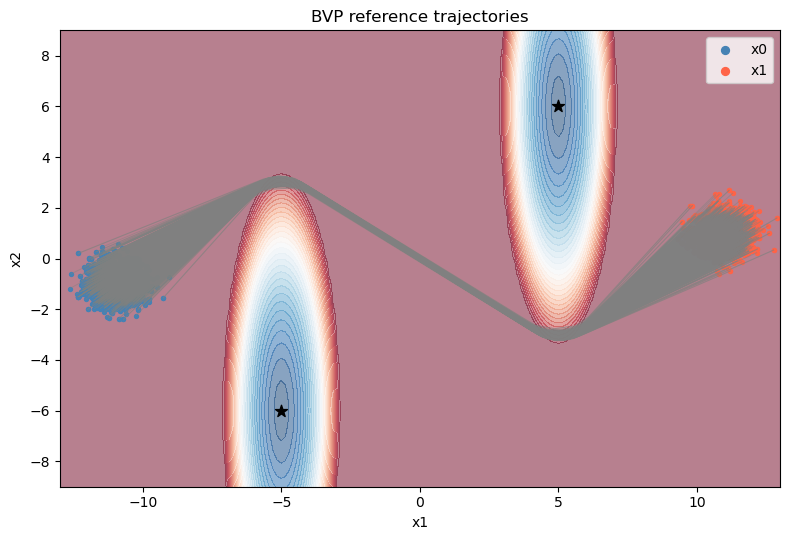

In [32]:
# Visualize a few BVP-solved trajectories.
n_show = min(n_dataset, n_dataset)
traj_bvp = to_numpy(states[:n_show, :, :dim])  # (pairs, time, x-position)
x0_coupled_plot = to_numpy(x0_coupled[:n_show])
x1_coupled_plot = to_numpy(x1_coupled[:n_show])
stunnel_centers_plot = to_numpy(stunnel_centers)

plt.figure(figsize=(8, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.5)
for i in range(n_show):
    plt.plot(traj_bvp[i, :, 0], traj_bvp[i, :, 1], 'gray', alpha=0.45, linewidth=0.7)
plt.scatter(x0_coupled_plot[:, 0], x0_coupled_plot[:, 1], s=8, c='steelblue', label='x0')
plt.scatter(x1_coupled_plot[:, 0], x1_coupled_plot[:, 1], s=8, c='tomato', label='x1')
plt.scatter(stunnel_centers_plot[:, 0], stunnel_centers_plot[:, 1], s=80, marker='*', c='black')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title('BVP reference trajectories')
plt.tight_layout()
plt.show()

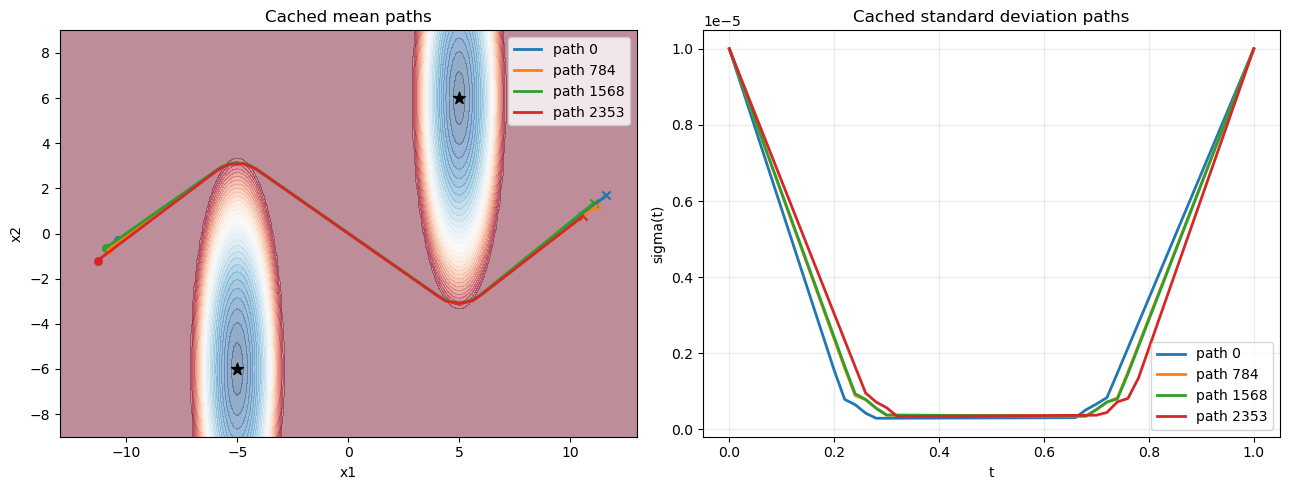

In [33]:
# Plot four cached mean paths and their standard deviation schedules.
n_mean_std_show = min(4, states.shape[0])
plot_idx = torch.linspace(0, states.shape[0] - 1, n_mean_std_show).long()
t_state = to_numpy(path.t_grid[:states.shape[1]])
mean_paths = to_numpy(states[plot_idx, :, :dim])
sigma_paths = to_numpy(states[plot_idx, :, 2 * dim])
colors = plt.cm.tab10(np.arange(n_mean_std_show))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.45)
axes[0].scatter(stunnel_centers_plot[:, 0], stunnel_centers_plot[:, 1], s=80, marker='*', c='black')
for j, idx in enumerate(plot_idx.tolist()):
    axes[0].plot(mean_paths[j, :, 0], mean_paths[j, :, 1], color=colors[j], linewidth=2.0, label=f'path {idx}')
    axes[0].scatter(mean_paths[j, 0, 0], mean_paths[j, 0, 1], s=30, color=colors[j], marker='o')
    axes[0].scatter(mean_paths[j, -1, 0], mean_paths[j, -1, 1], s=35, color=colors[j], marker='x')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('Cached mean paths')
axes[0].legend()

for j, idx in enumerate(plot_idx.tolist()):
    axes[1].plot(t_state, sigma_paths[j], color=colors[j], linewidth=2.0, label=f'path {idx}')
axes[1].set_xlabel('t')
axes[1].set_ylabel('sigma(t)')
axes[1].set_title('Cached standard deviation paths')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


## Model and Training

In [42]:
model = MLP(dim + 1, out_dim=dim, w=512).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

x0_coupled = x0_coupled.to(device)
x1_coupled = x1_coupled.to(device)

model.train()
losses = []

for k in range(n_iters):
    optimizer.zero_grad()

    idx = torch.randint(0, n_dataset, (batch_size,), device=device)
    x0_b = x0_coupled[idx]
    x1_b = x1_coupled[idx]

    t = torch.rand((batch_size, 1), device=device)
    epsilon = torch.randn_like(x0_b)
    xt = path.sample_xt(x0_b, x1_b, t, epsilon)
    ut = path.compute_ut(x0_b, x1_b, t, xt)

    vt = model(torch.cat([xt, t], dim=-1))
    loss = flow_matching_loss(vt, ut)

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if k % 1000 == 0 or k == n_iters - 1:
        print(f'step {k:5d}: loss = {loss.item():.5f}')

/opt/conda/conda-bld/pytorch_1695392020201/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): block: [0,0,0], thread: [102,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/opt/conda/conda-bld/pytorch_1695392020201/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): block: [0,0,0], thread: [103,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/opt/conda/conda-bld/pytorch_1695392020201/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): block: [0,0,0], thread: [108,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/opt/conda/conda-bld/pytorch_1695392020201/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): block: [0,0,0], thread: [109,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/opt/conda/conda-bld/pytorch_1695392020201/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): blo

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


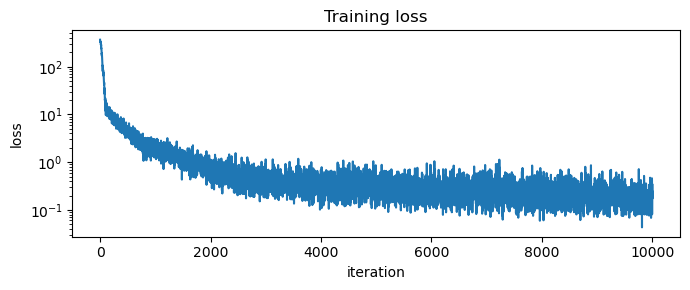

In [38]:
plt.figure(figsize=(7, 3))
plt.semilogy(losses)
plt.xlabel('iteration')
plt.ylabel('loss')
plt.title('Training loss')
plt.tight_layout()
plt.show()

## Evaluation

In [43]:
model.eval()
node = NeuralODE(torch_wrapper(model), sensitivity='adjoint', solver='euler')

with torch.no_grad():
    traj = node.trajectory(
        sample_source(500).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )

traj_plot = to_numpy(traj)

fig = plot_trajectories_with_potential(traj_plot, X, Y, Z, n=500)
fig.suptitle('Learned trajectories through the stunnel potential')
plt.tight_layout()
plt.show()

x1_ref = to_numpy(sample_target(500))
stunnel_centers_plot = to_numpy(stunnel_centers)
plt.figure(figsize=(7, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.4)
plt.scatter(traj_plot[-1, :, 0], traj_plot[-1, :, 1], s=5, c='tomato', label='generated')
plt.scatter(x1_ref[:, 0], x1_ref[:, 1], s=5, c='seagreen', label='target')
plt.scatter(stunnel_centers_plot[:, 0], stunnel_centers_plot[:, 1], s=80, marker='*', c='black')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title('Generated terminal samples vs target')
plt.tight_layout()
plt.show()

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


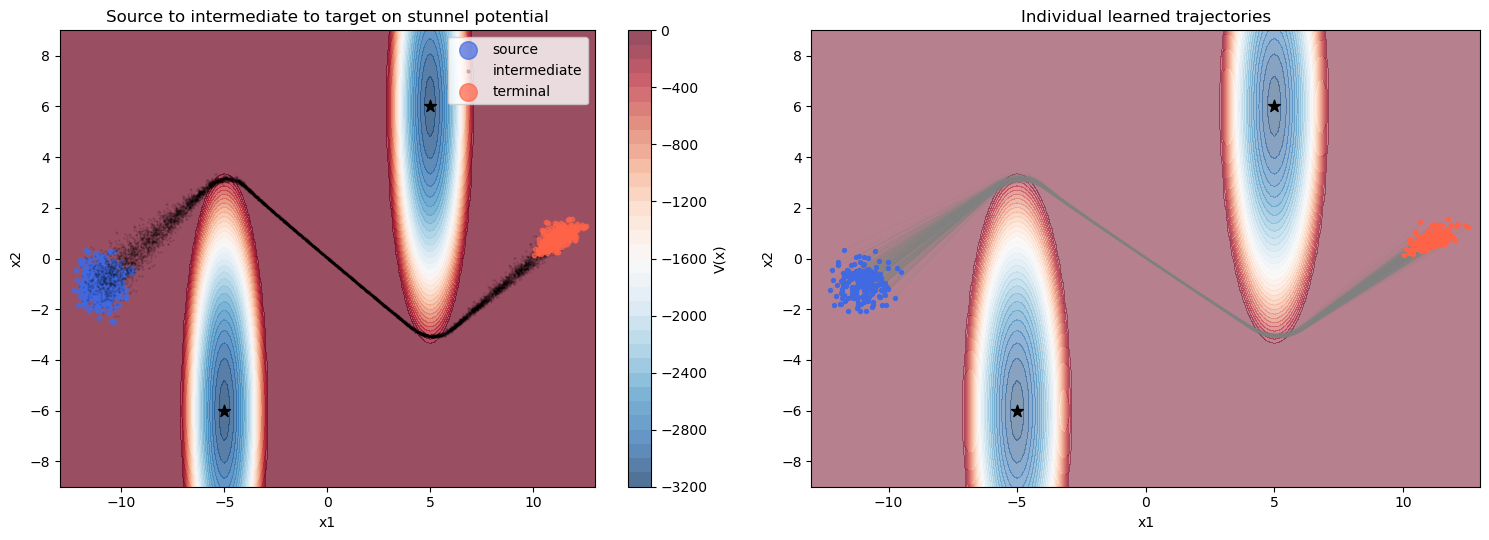

In [44]:
# Source, intermediate, and target states plus individual trajectory paths.
n_show = 500
n_lines = 200

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

cf = axes[0].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.7)
plt.colorbar(cf, ax=axes[0], label='V(x)')
axes[0].scatter(traj_plot[0, :n_show, 0], traj_plot[0, :n_show, 1], s=10, alpha=0.7, c='royalblue', label='source')
axes[0].scatter(traj_plot[1:-1:5, :n_show, 0].reshape(-1), traj_plot[1:-1:5, :n_show, 1].reshape(-1), s=0.3, alpha=0.15, c='black', label='intermediate')
axes[0].scatter(traj_plot[-1, :n_show, 0], traj_plot[-1, :n_show, 1], s=10, alpha=0.7, c='tomato', label='terminal')
axes[0].scatter(stunnel_centers_plot[:, 0], stunnel_centers_plot[:, 1], s=80, marker='*', c='black')
axes[0].legend(markerscale=4)
axes[0].set_title('Source to intermediate to target on stunnel potential')

axes[1].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.5)
for i in range(n_lines):
    axes[1].plot(traj_plot[:, i, 0], traj_plot[:, i, 1], 'gray', alpha=0.2, linewidth=0.6)
axes[1].scatter(traj_plot[0, :n_lines, 0], traj_plot[0, :n_lines, 1], s=8, c='royalblue', zorder=3)
axes[1].scatter(traj_plot[-1, :n_lines, 0], traj_plot[-1, :n_lines, 1], s=8, c='tomato', zorder=3)
axes[1].scatter(stunnel_centers_plot[:, 0], stunnel_centers_plot[:, 1], s=80, marker='*', c='black', zorder=4)
axes[1].set_title('Individual learned trajectories')

for ax in axes:
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_xlim(-13, 13)
    ax.set_ylim(-9, 9)

plt.tight_layout()
plt.show()